# 🎮 Video Game Sales & Engagement Analysis
## Exploratory Data Analysis (EDA)
---
**Datasets:** `cleaned_games.csv` (1,099 rows) | `cleaned_vgsales.csv` (16,593 rows) | `merged_data.csv` (1,099 rows)

**Sections:**
1. Setup & Data Load
2. Univariate Analysis — Ratings, Sales, Engagement
3. Genre Analysis
4. Platform & Publisher Analysis
5. Yearly Trends
6. Correlation & Bivariate Analysis
7. Top Games Dashboard
8. Key Insights Summary


## 1. Setup & Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Plot Style ─────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : '#0f0f1a',
    'axes.facecolor'   : '#1a1a2e',
    'axes.edgecolor'   : '#444466',
    'axes.labelcolor'  : '#ccccff',
    'axes.titlecolor'  : '#ffffff',
    'xtick.color'      : '#aaaacc',
    'ytick.color'      : '#aaaacc',
    'text.color'       : '#ffffff',
    'grid.color'       : '#2a2a4a',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.5,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 14,
    'axes.labelsize'   : 11,
})

PALETTE   = ['#7c83fd', '#fd7c7c', '#7cfdcb', '#fdd97c', '#fd7cf0', '#7ccffd']
ACCENT    = '#7c83fd'

print('✅ Libraries & plot style loaded')

✅ Libraries & plot style loaded


In [2]:
games   = pd.read_csv('cleaned_data/cleaned_games.csv')
vgsales = pd.read_csv('cleaned_data/cleaned_vgsales.csv')
merged  = pd.read_csv('cleaned_data/merged_data.csv')

# Only matched games for sales analysis
matched = merged[merged['Global_Sales'] > 0].copy()

print(f'games   : {games.shape}')
print(f'vgsales : {vgsales.shape}')
print(f'merged  : {merged.shape}')
print(f'matched (both datasets) : {matched.shape}')
display(games.head(3))

games   : (1099, 19)
vgsales : (16593, 15)
merged  : (1099, 27)
matched (both datasets) : (469, 27)


,Game_Title,Release Date,Rating,Times Listed,Number of Reviews,Plays,Playing,Backlogs,Wishlist,Release_Year,Release_Month,Primary_Genre,Primary_Developer,Genres_Clean,Team_Clean,Engagement_Score,Demand_Index,Rating_Tier,game_id
0,Elden Ring,2022-02-25,4.5,3900.0,3900.0,17000.0,3800.0,4600.0,4800.0,2022.0,2.0,Adventure,Bandai Namco Entertainment,"Adventure, RPG","Bandai Namco Entertainment, FromSoftware",33.50,0.282336,High (4+),1
1,Hades,2019-12-10,4.3,2900.0,2900.0,21000.0,3200.0,6300.0,3600.0,2019.0,12.0,Adventure,Supergiant Games,"Adventure, Brawler, Indie, RPG",Supergiant Games,37.65,0.171420,High (4+),2
2,The Legend of Zelda: Breath of the Wild,2017-03-03,4.4,4300.0,4300.0,30000.0,2500.0,5000.0,2600.0,2017.0,3.0,Adventure,Nintendo,"Adventure, RPG","Nintendo, Nintendo EPD Production Group No. 3",42.70,0.086664,High (4+),3


## 2. Univariate Analysis

### 2.1 Rating Distribution

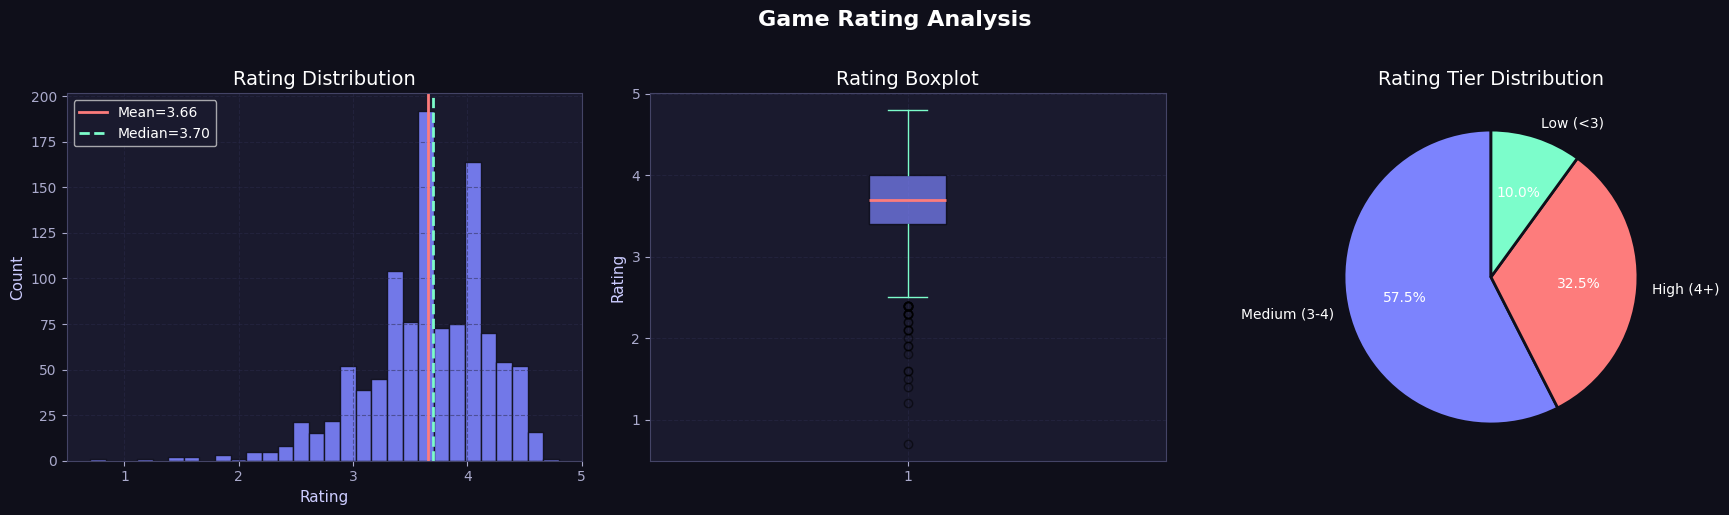

Mean Rating: 3.66 | Median: 3.70 | Std: 0.54


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Game Rating Analysis', fontsize=16, fontweight='bold', y=1.02)

# Histogram
axes[0].hist(games['Rating'].dropna(), bins=30, color=PALETTE[0], edgecolor='#0f0f1a', alpha=0.9)
axes[0].axvline(games['Rating'].mean(),   color=PALETTE[1], lw=2, label=f'Mean={games["Rating"].mean():.2f}')
axes[0].axvline(games['Rating'].median(), color=PALETTE[2], lw=2, ls='--', label=f'Median={games["Rating"].median():.2f}')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Count')
axes[0].legend(); axes[0].grid(True)

# Boxplot
bp = axes[1].boxplot(games['Rating'].dropna(), patch_artist=True, vert=True,
    boxprops=dict(facecolor=PALETTE[0], alpha=0.7),
    medianprops=dict(color=PALETTE[1], lw=2),
    whiskerprops=dict(color=PALETTE[2]),
    capprops=dict(color=PALETTE[2]),
    flierprops=dict(marker='o', color=PALETTE[1], alpha=0.5))
axes[1].set_title('Rating Boxplot')
axes[1].set_ylabel('Rating'); axes[1].grid(True)

# Rating tier pie
def rate_tier(r):
    if r >= 4.0: return 'High (4+)'
    if r >= 3.0: return 'Medium (3-4)'
    return 'Low (<3)'
tier_counts = games['Rating'].dropna().apply(rate_tier).value_counts()
axes[2].pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%',
    colors=PALETTE[:3], startangle=90,
    wedgeprops=dict(edgecolor='#0f0f1a', linewidth=2))
axes[2].set_title('Rating Tier Distribution')

plt.tight_layout()
plt.savefig('eda_rating.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print(f'Mean Rating: {games["Rating"].mean():.2f} | Median: {games["Rating"].median():.2f} | Std: {games["Rating"].std():.2f}')

### 2.2 Global Sales Distribution

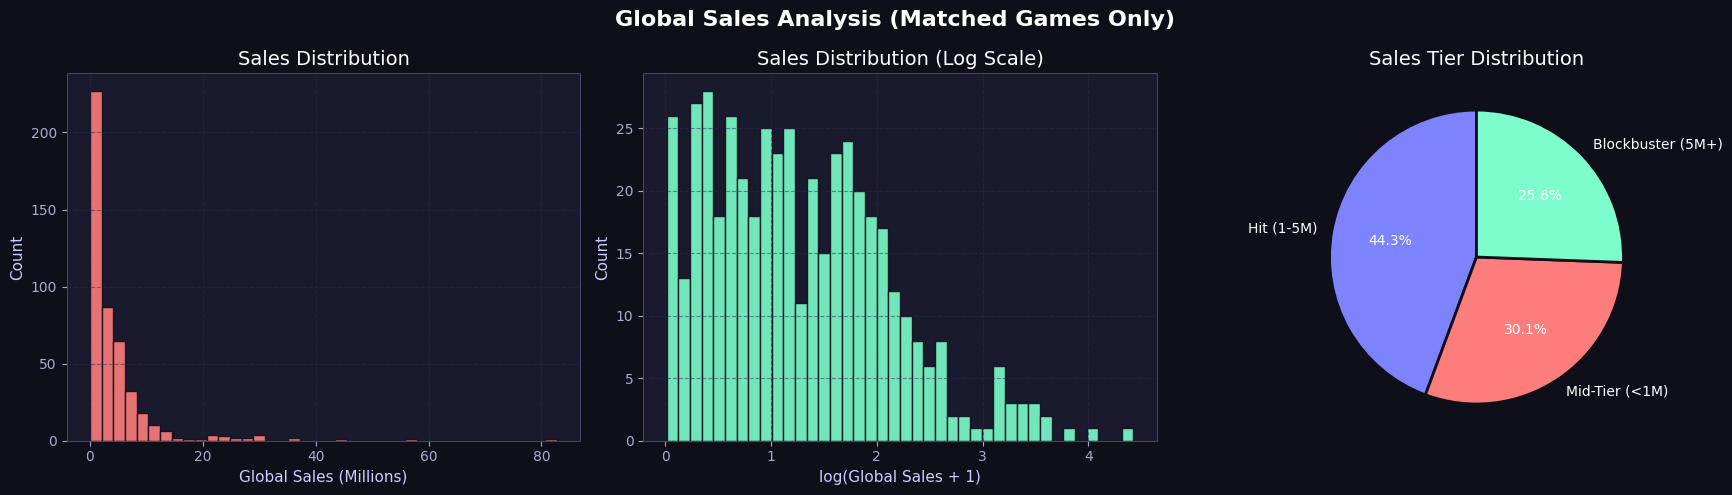

Max: 82.74M | Mean: 4.45M | Median: 2.19M


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Global Sales Analysis (Matched Games Only)', fontsize=16, fontweight='bold')

# Log scale histogram
axes[0].hist(matched['Global_Sales'], bins=40, color=PALETTE[1], edgecolor='#0f0f1a', alpha=0.9)
axes[0].set_title('Sales Distribution')
axes[0].set_xlabel('Global Sales (Millions)'); axes[0].set_ylabel('Count')
axes[0].grid(True)

# Log scale
axes[1].hist(np.log1p(matched['Global_Sales']), bins=40, color=PALETTE[2], edgecolor='#0f0f1a', alpha=0.9)
axes[1].set_title('Sales Distribution (Log Scale)')
axes[1].set_xlabel('log(Global Sales + 1)'); axes[1].set_ylabel('Count')
axes[1].grid(True)

# Sales tier pie
def s_tier(v):
    if v >= 5:  return 'Blockbuster (5M+)'
    if v >= 1:  return 'Hit (1-5M)'
    return 'Mid-Tier (<1M)'
stier = matched['Global_Sales'].apply(s_tier).value_counts()
axes[2].pie(stier, labels=stier.index, autopct='%1.1f%%',
    colors=PALETTE[:3], startangle=90,
    wedgeprops=dict(edgecolor='#0f0f1a', linewidth=2))
axes[2].set_title('Sales Tier Distribution')

plt.tight_layout()
plt.savefig('eda_sales_dist.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print(f'Max: {matched["Global_Sales"].max()}M | Mean: {matched["Global_Sales"].mean():.2f}M | Median: {matched["Global_Sales"].median():.2f}M')

### 2.3 Engagement Metrics Overview

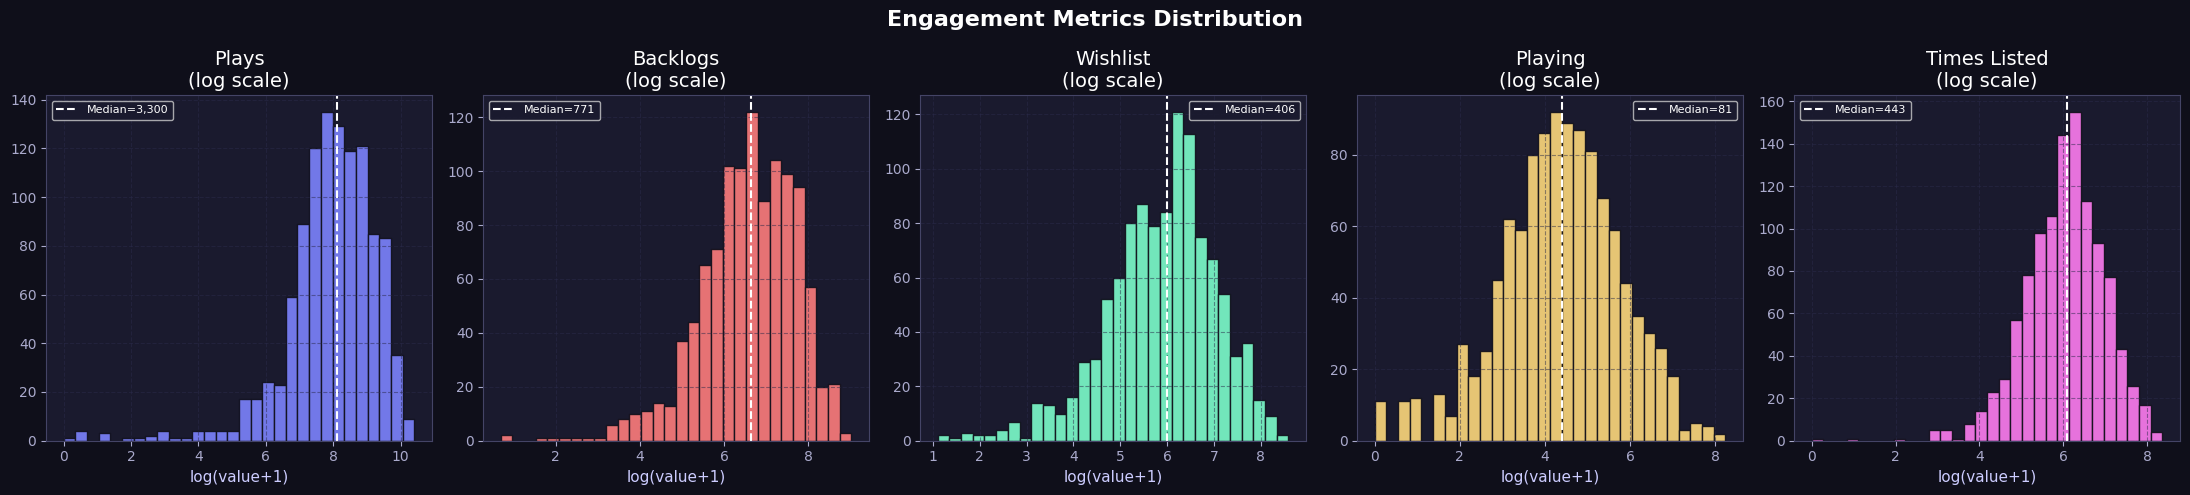

Engagement Summary:


,Plays,Backlogs,Wishlist,Playing,Times Listed
count,1099.0,1099.0,1099.0,1099.0,1099.0
mean,4975.0,1167.0,611.0,187.0,606.0
std,4971.0,1133.0,661.0,322.0,561.0
min,0.0,1.0,2.0,0.0,0.0
25%,1500.0,382.0,178.0,32.0,233.0
50%,3300.0,771.0,406.0,81.0,443.0
75%,6700.0,1600.0,764.0,200.0,776.0
max,33000.0,8300.0,5400.0,3800.0,4300.0


In [5]:
eng_cols = ['Plays', 'Backlogs', 'Wishlist', 'Playing', 'Times Listed']
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle('Engagement Metrics Distribution', fontsize=16, fontweight='bold')

for i, col in enumerate(eng_cols):
    data = games[col].dropna()
    axes[i].hist(np.log1p(data), bins=30, color=PALETTE[i % len(PALETTE)],
                 edgecolor='#0f0f1a', alpha=0.9)
    axes[i].set_title(f'{col}\n(log scale)')
    axes[i].set_xlabel('log(value+1)')
    axes[i].grid(True)
    med = data.median()
    axes[i].axvline(np.log1p(med), color='white', lw=1.5, ls='--', label=f'Median={med:,.0f}')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('eda_engagement.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print('Engagement Summary:')
display(games[eng_cols].describe().round(0))

## 3. Genre Analysis

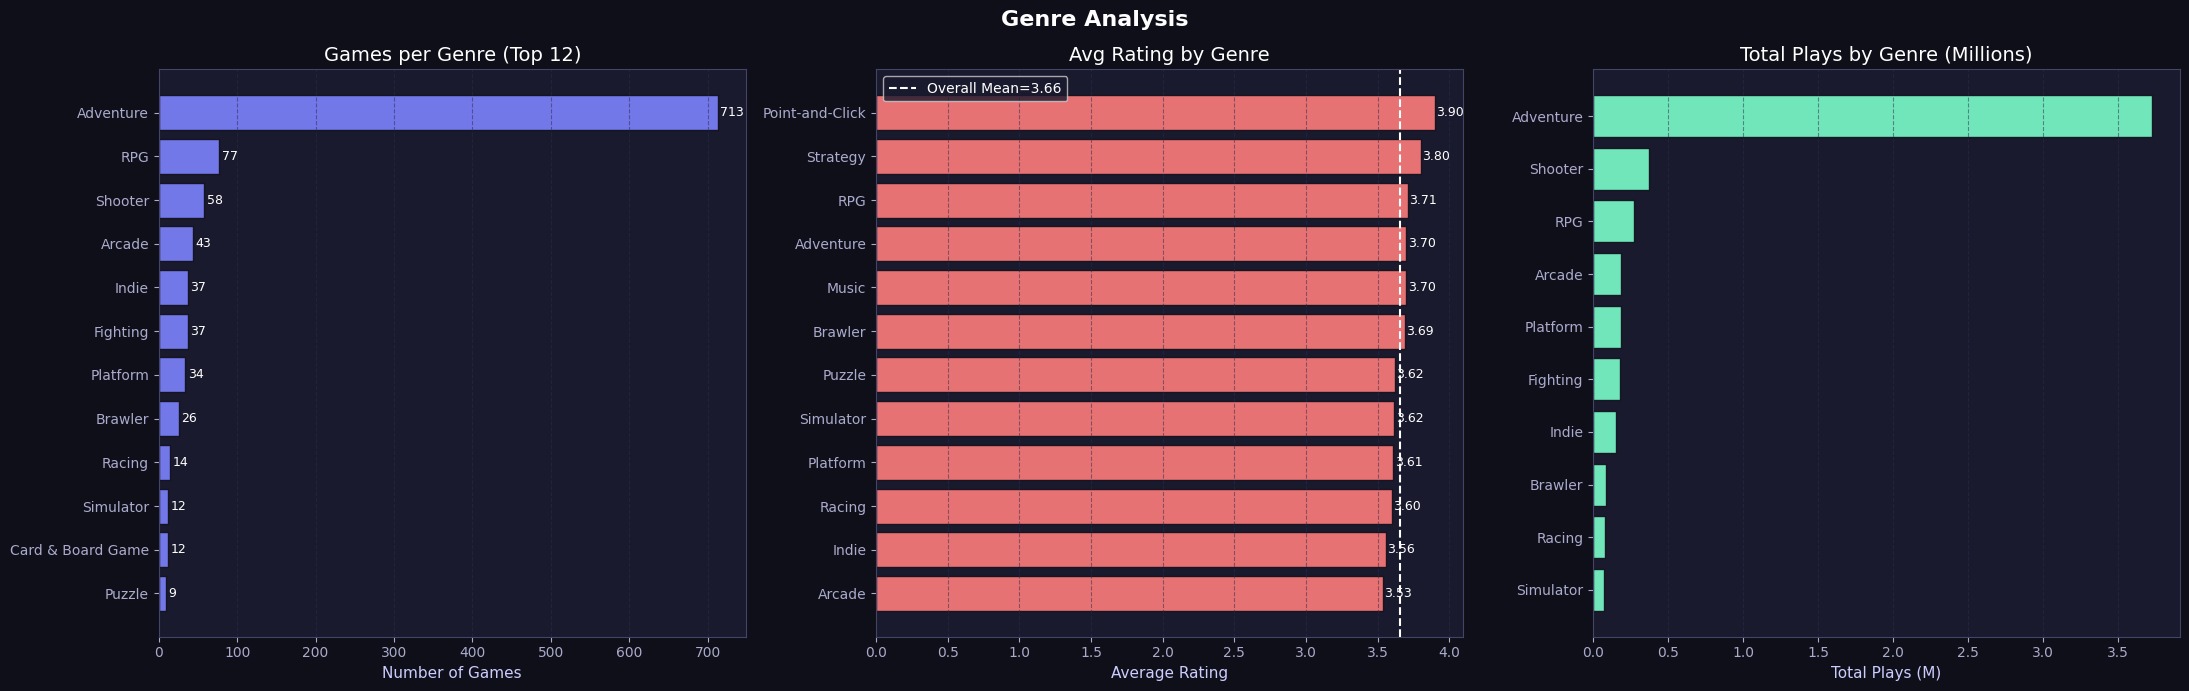

In [6]:
# Genre counts
genre_counts = games['Primary_Genre'].value_counts()
genre_rating = games.groupby('Primary_Genre')['Rating'].mean().sort_values(ascending=False)
genre_plays  = games.groupby('Primary_Genre')['Plays'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Genre Analysis', fontsize=16, fontweight='bold')

# Games per genre
top_genres = genre_counts.head(12)
bars = axes[0].barh(top_genres.index[::-1], top_genres.values[::-1],
                    color=PALETTE[0], edgecolor='#0f0f1a', alpha=0.9)
axes[0].set_title('Games per Genre (Top 12)')
axes[0].set_xlabel('Number of Games')
axes[0].grid(True, axis='x')
for bar, val in zip(bars, top_genres.values[::-1]):
    axes[0].text(bar.get_width()+3, bar.get_y()+bar.get_height()/2,
                 str(val), va='center', fontsize=9, color='white')

# Avg rating per genre
top_r = genre_rating.head(12)
colors_r = [PALETTE[0] if r >= 4.0 else PALETTE[1] if r >= 3.5 else PALETTE[3] for r in top_r.values]
bars2 = axes[1].barh(top_r.index[::-1], top_r.values[::-1],
                     color=colors_r[::-1], edgecolor='#0f0f1a', alpha=0.9)
axes[1].axvline(games['Rating'].mean(), color='white', lw=1.5, ls='--', label=f'Overall Mean={games["Rating"].mean():.2f}')
axes[1].set_title('Avg Rating by Genre')
axes[1].set_xlabel('Average Rating')
axes[1].legend(); axes[1].grid(True, axis='x')
for bar, val in zip(bars2, top_r.values[::-1]):
    axes[1].text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=9, color='white')

# Total plays per genre
top_p = genre_plays.head(10)
bars3 = axes[2].barh(top_p.index[::-1], top_p.values[::-1]/1e6,
                     color=PALETTE[2], edgecolor='#0f0f1a', alpha=0.9)
axes[2].set_title('Total Plays by Genre (Millions)')
axes[2].set_xlabel('Total Plays (M)')
axes[2].grid(True, axis='x')

plt.tight_layout()
plt.savefig('eda_genre.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

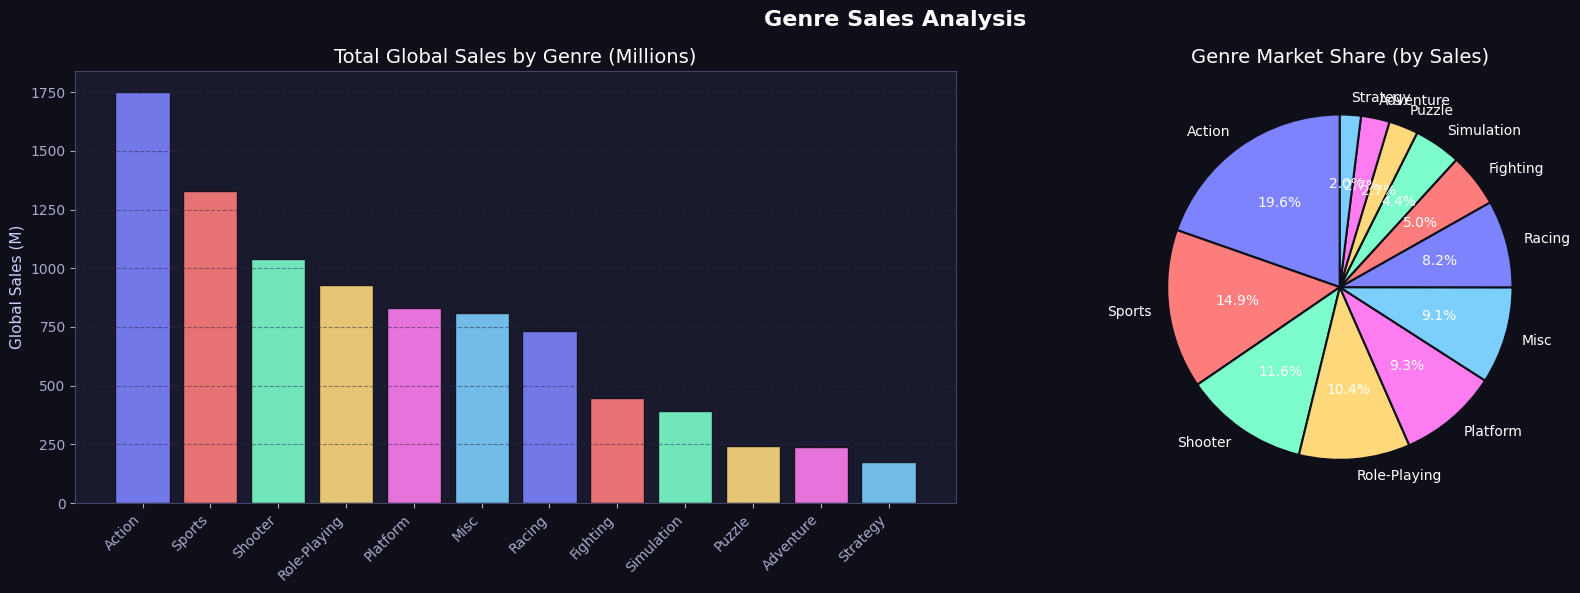

Top 5 Genres by Sales (Millions):
Genre
Action          1751.18
Sports          1330.92
Shooter         1037.35
Role-Playing     927.37
Platform         830.89


In [7]:
# Genre Sales (vgsales)
genre_sales = vgsales.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False).head(12)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Genre Sales Analysis', fontsize=16, fontweight='bold')

# Sales bar
bars = axes[0].bar(range(len(genre_sales)), genre_sales.values,
                   color=PALETTE[:len(genre_sales)], edgecolor='#0f0f1a', alpha=0.9)
axes[0].set_xticks(range(len(genre_sales)))
axes[0].set_xticklabels(genre_sales.index, rotation=45, ha='right')
axes[0].set_title('Total Global Sales by Genre (Millions)')
axes[0].set_ylabel('Global Sales (M)')
axes[0].grid(True, axis='y')

# Market share pie
axes[1].pie(genre_sales.values, labels=genre_sales.index, autopct='%1.1f%%',
    colors=PALETTE * 2, startangle=90,
    wedgeprops=dict(edgecolor='#0f0f1a', linewidth=1.5))
axes[1].set_title('Genre Market Share (by Sales)')

plt.tight_layout()
plt.savefig('eda_genre_sales.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print('Top 5 Genres by Sales (Millions):')
print(genre_sales.head(5).to_string())

## 4. Platform & Publisher Analysis

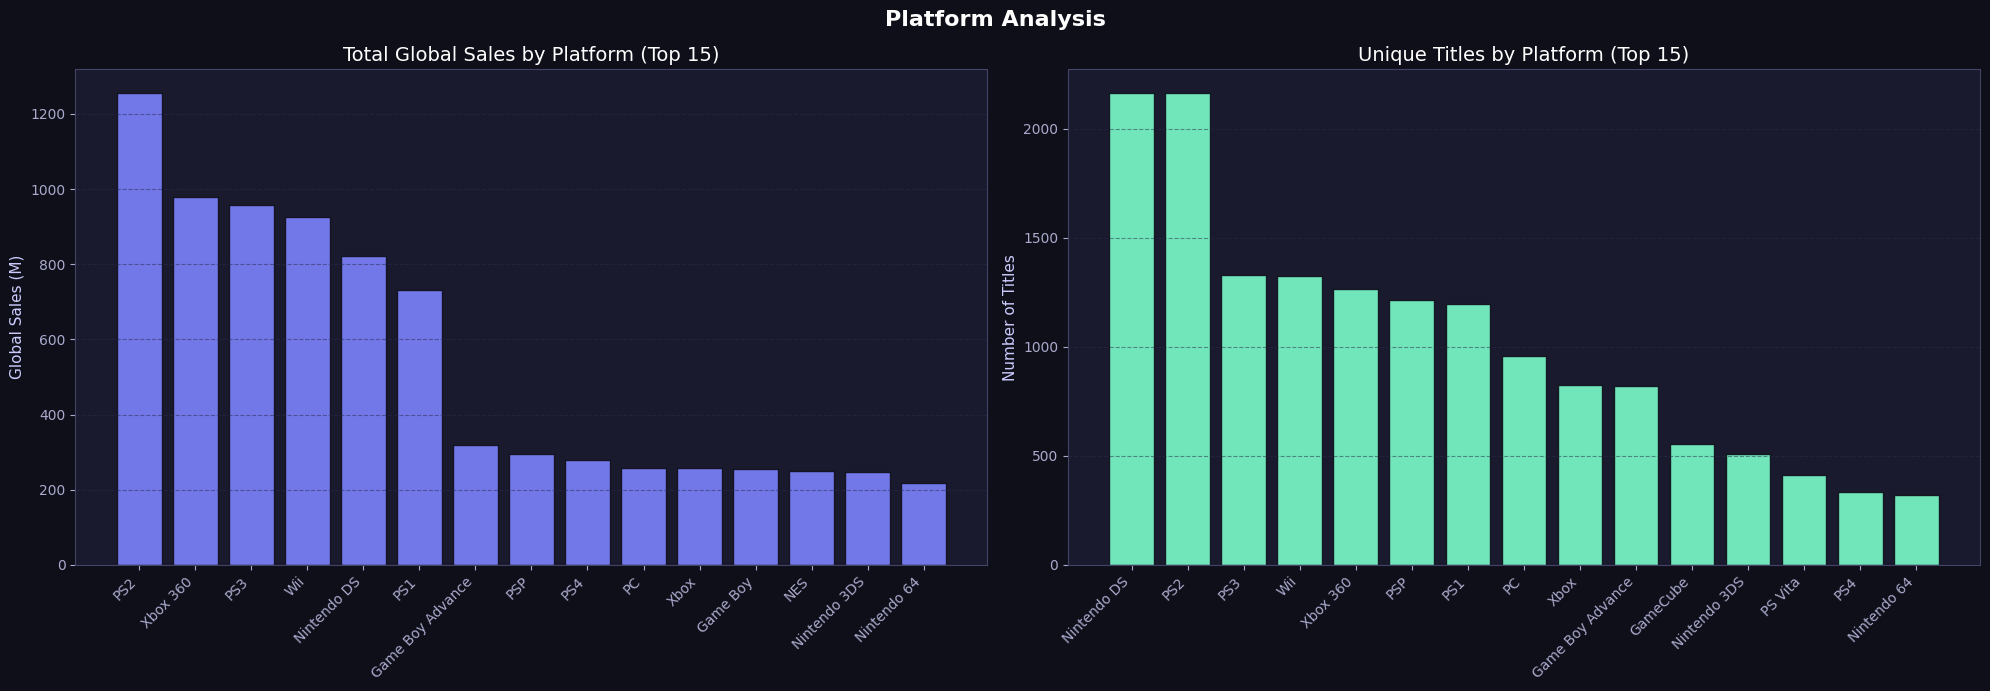

In [8]:
plat_sales  = vgsales.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head(15)
plat_titles = vgsales.groupby('Platform')['Game_Title'].nunique().sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Platform Analysis', fontsize=16, fontweight='bold')

# Sales by platform
bars = axes[0].bar(range(len(plat_sales)), plat_sales.values,
                   color=PALETTE[0], edgecolor='#0f0f1a', alpha=0.9)
axes[0].set_xticks(range(len(plat_sales)))
axes[0].set_xticklabels(plat_sales.index, rotation=45, ha='right')
axes[0].set_title('Total Global Sales by Platform (Top 15)')
axes[0].set_ylabel('Global Sales (M)')
axes[0].grid(True, axis='y')

# Titles by platform
bars2 = axes[1].bar(range(len(plat_titles)), plat_titles.values,
                    color=PALETTE[2], edgecolor='#0f0f1a', alpha=0.9)
axes[1].set_xticks(range(len(plat_titles)))
axes[1].set_xticklabels(plat_titles.index, rotation=45, ha='right')
axes[1].set_title('Unique Titles by Platform (Top 15)')
axes[1].set_ylabel('Number of Titles')
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.savefig('eda_platform.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

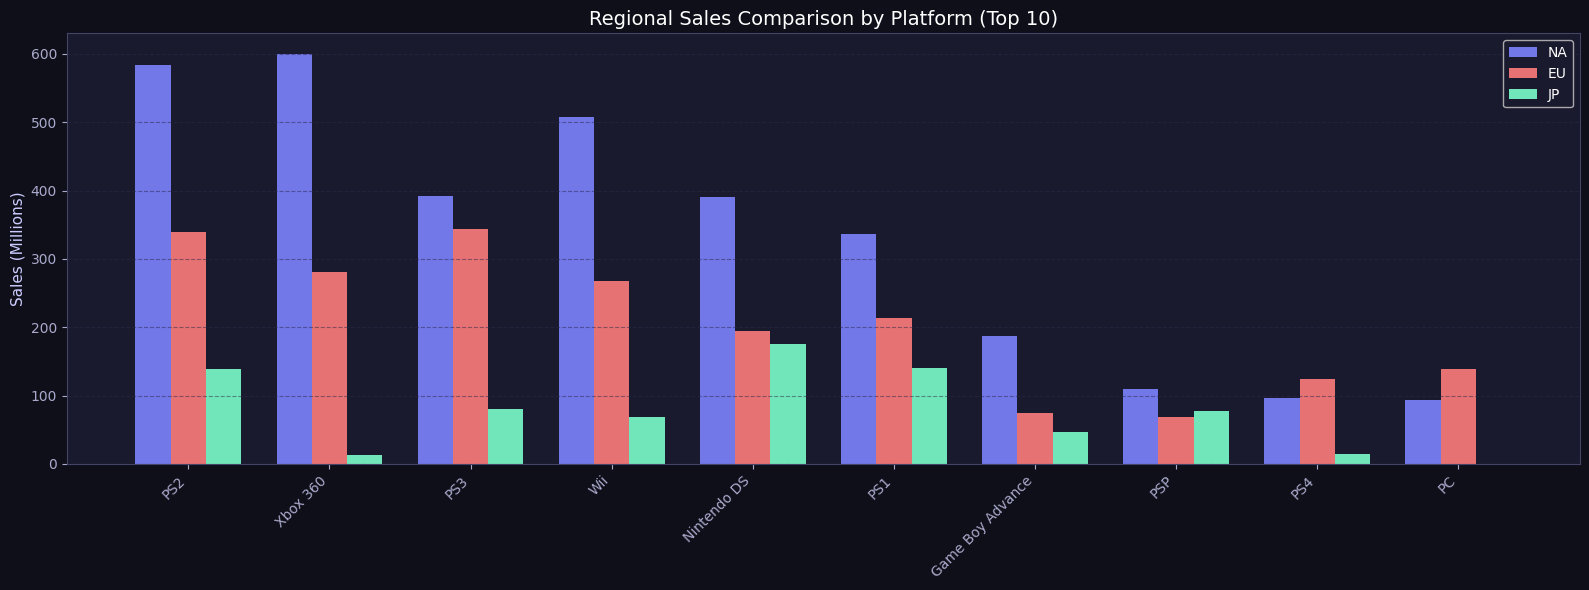

In [9]:
# Regional sales comparison by platform
top_plats = vgsales.groupby('Platform')['Global_Sales'].sum().nlargest(10).index
plat_regional = vgsales[vgsales['Platform'].isin(top_plats)].groupby('Platform')[['NA_Sales','EU_Sales','JP_Sales']].sum()
plat_regional = plat_regional.loc[top_plats]

x = range(len(plat_regional))
width = 0.25
fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('#0f0f1a')

ax.bar([i-width for i in x], plat_regional['NA_Sales'], width, label='NA', color=PALETTE[0], alpha=0.9)
ax.bar(x,                     plat_regional['EU_Sales'], width, label='EU', color=PALETTE[1], alpha=0.9)
ax.bar([i+width for i in x], plat_regional['JP_Sales'], width, label='JP', color=PALETTE[2], alpha=0.9)

ax.set_xticks(list(x))
ax.set_xticklabels(plat_regional.index, rotation=45, ha='right')
ax.set_title('Regional Sales Comparison by Platform (Top 10)', fontsize=14)
ax.set_ylabel('Sales (Millions)')
ax.legend(); ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('eda_regional.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

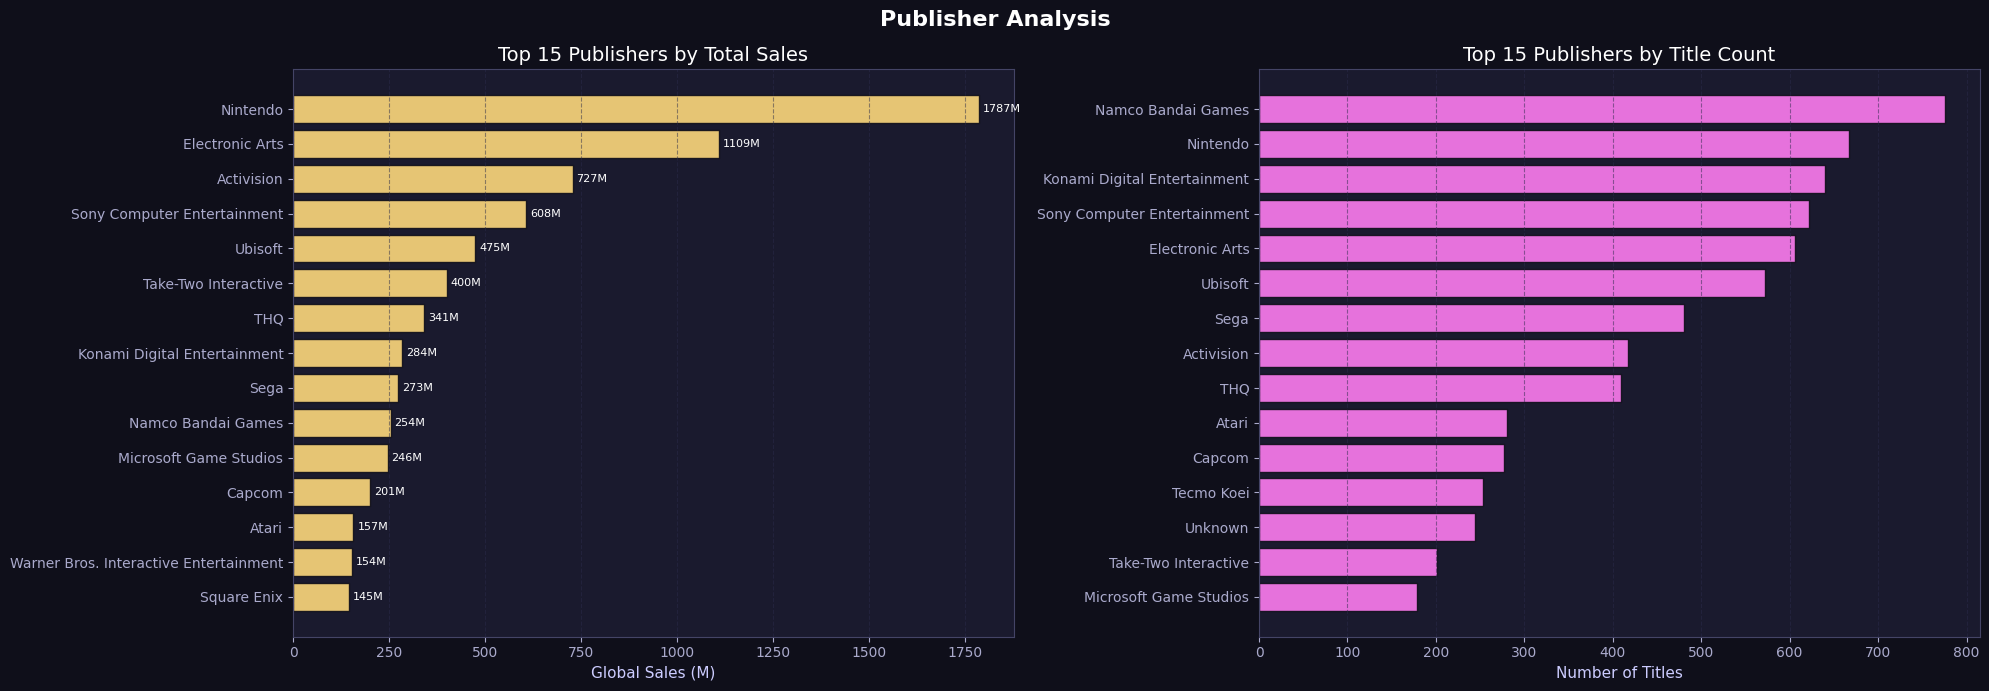

In [10]:
# Top Publishers
pub_sales  = vgsales.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(15)
pub_titles = vgsales.groupby('Publisher')['Game_Title'].nunique().sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Publisher Analysis', fontsize=16, fontweight='bold')

bars = axes[0].barh(pub_sales.index[::-1], pub_sales.values[::-1],
                    color=PALETTE[3], edgecolor='#0f0f1a', alpha=0.9)
axes[0].set_title('Top 15 Publishers by Total Sales')
axes[0].set_xlabel('Global Sales (M)')
axes[0].grid(True, axis='x')
for bar, val in zip(bars, pub_sales.values[::-1]):
    axes[0].text(bar.get_width()+10, bar.get_y()+bar.get_height()/2,
                 f'{val:.0f}M', va='center', fontsize=8, color='white')

bars2 = axes[1].barh(pub_titles.index[::-1], pub_titles.values[::-1],
                     color=PALETTE[4], edgecolor='#0f0f1a', alpha=0.9)
axes[1].set_title('Top 15 Publishers by Title Count')
axes[1].set_xlabel('Number of Titles')
axes[1].grid(True, axis='x')

plt.tight_layout()
plt.savefig('eda_publisher.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 5. Yearly Trends

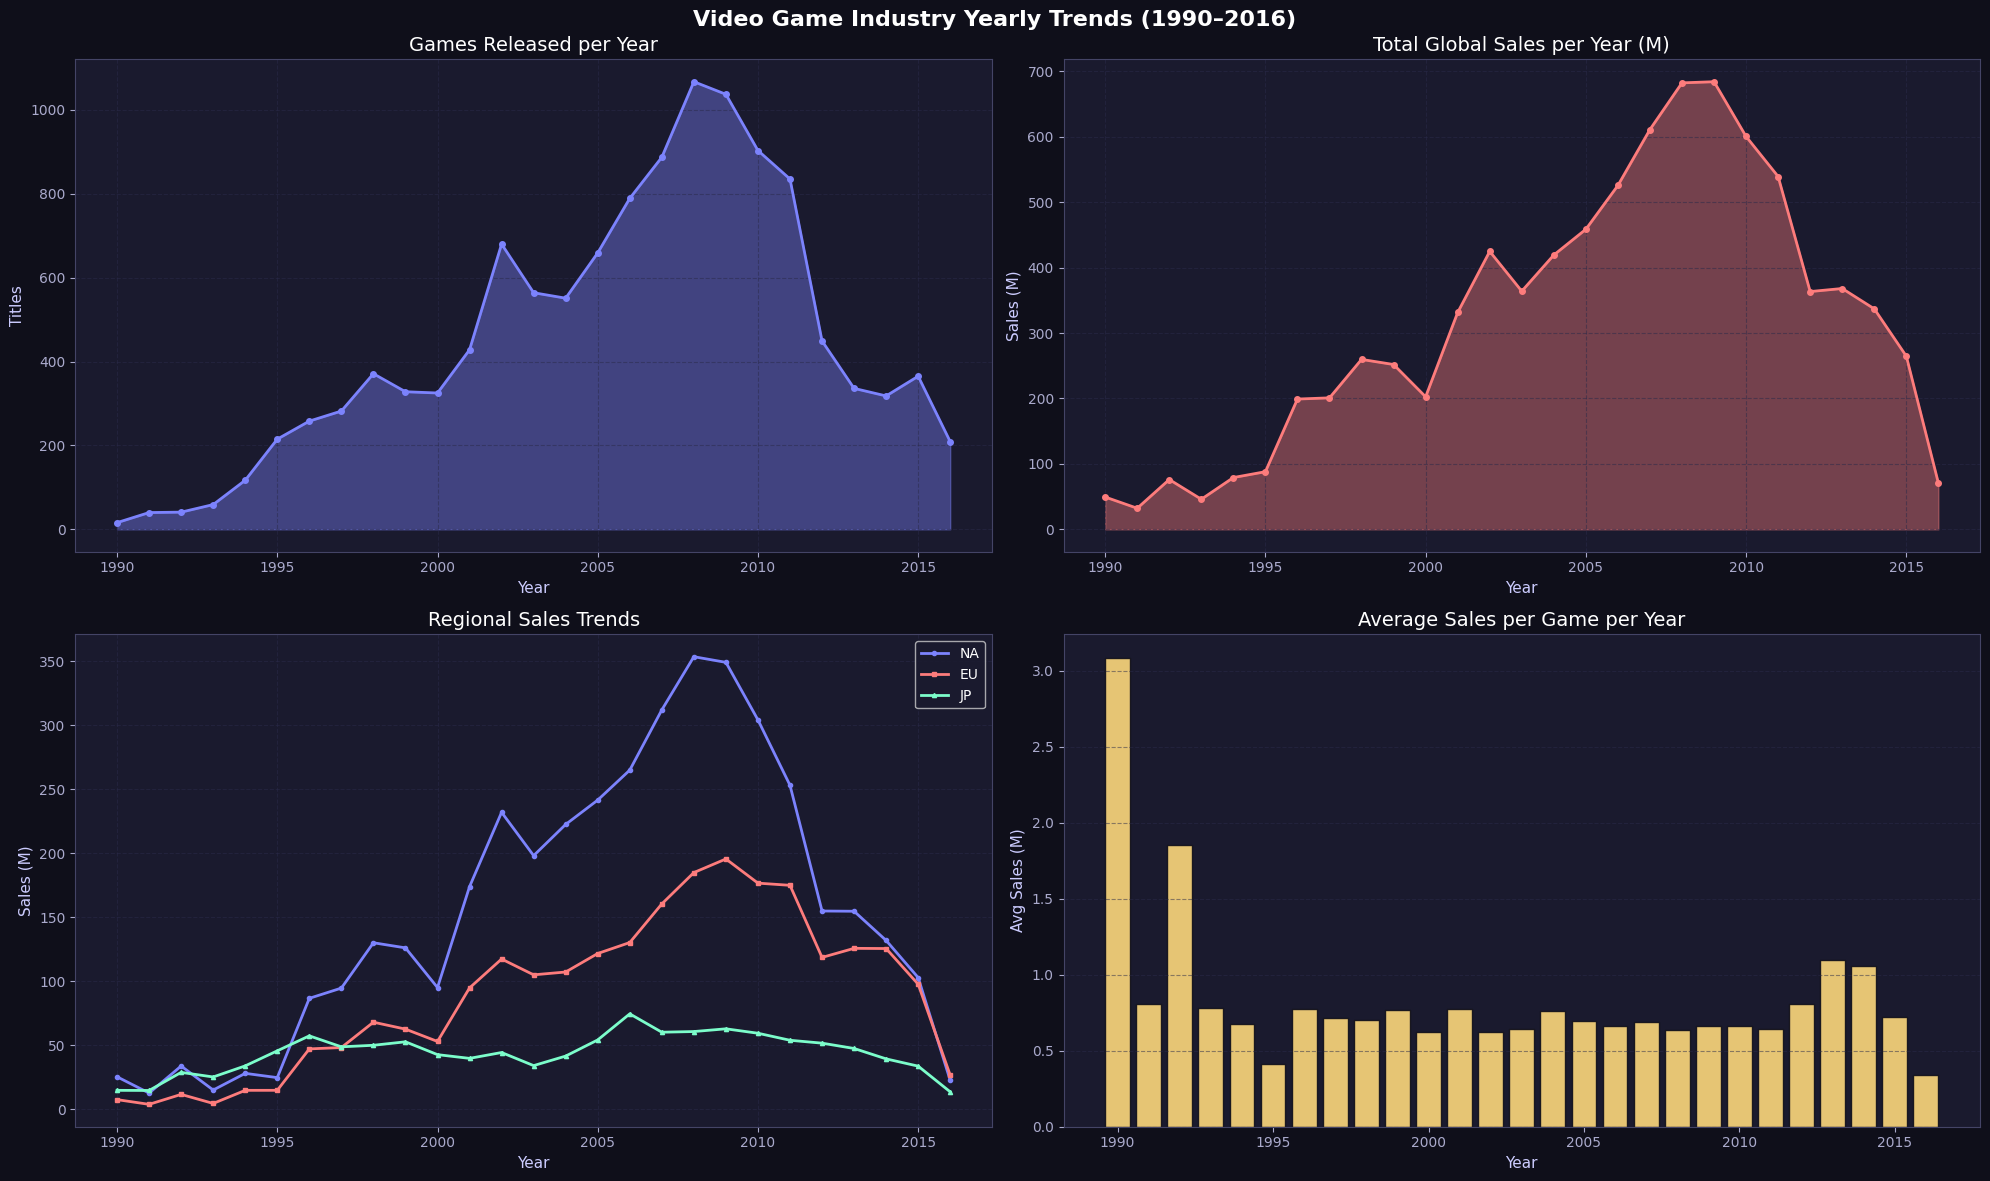

In [11]:
yearly = vgsales.groupby('Year').agg(
    games_released = ('Game_Title', 'nunique'),
    global_sales   = ('Global_Sales', 'sum'),
    na_sales       = ('NA_Sales', 'sum'),
    eu_sales       = ('EU_Sales', 'sum'),
    jp_sales       = ('JP_Sales', 'sum')
).reset_index()
yearly = yearly[(yearly['Year'] >= 1990) & (yearly['Year'] <= 2016)]

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('Video Game Industry Yearly Trends (1990–2016)', fontsize=16, fontweight='bold')

# Games released per year
axes[0,0].fill_between(yearly['Year'], yearly['games_released'],
                        alpha=0.4, color=PALETTE[0])
axes[0,0].plot(yearly['Year'], yearly['games_released'],
               color=PALETTE[0], lw=2, marker='o', markersize=4)
axes[0,0].set_title('Games Released per Year')
axes[0,0].set_xlabel('Year'); axes[0,0].set_ylabel('Titles')
axes[0,0].grid(True)

# Global sales per year
axes[0,1].fill_between(yearly['Year'], yearly['global_sales'],
                        alpha=0.4, color=PALETTE[1])
axes[0,1].plot(yearly['Year'], yearly['global_sales'],
               color=PALETTE[1], lw=2, marker='o', markersize=4)
axes[0,1].set_title('Total Global Sales per Year (M)')
axes[0,1].set_xlabel('Year'); axes[0,1].set_ylabel('Sales (M)')
axes[0,1].grid(True)

# Regional trends
axes[1,0].plot(yearly['Year'], yearly['na_sales'], color=PALETTE[0], lw=2, label='NA', marker='o', markersize=3)
axes[1,0].plot(yearly['Year'], yearly['eu_sales'], color=PALETTE[1], lw=2, label='EU', marker='s', markersize=3)
axes[1,0].plot(yearly['Year'], yearly['jp_sales'], color=PALETTE[2], lw=2, label='JP', marker='^', markersize=3)
axes[1,0].set_title('Regional Sales Trends')
axes[1,0].set_xlabel('Year'); axes[1,0].set_ylabel('Sales (M)')
axes[1,0].legend(); axes[1,0].grid(True)

# Avg sales per game
yearly['avg_sales'] = yearly['global_sales'] / yearly['games_released']
axes[1,1].bar(yearly['Year'], yearly['avg_sales'], color=PALETTE[3], edgecolor='#0f0f1a', alpha=0.9)
axes[1,1].set_title('Average Sales per Game per Year')
axes[1,1].set_xlabel('Year'); axes[1,1].set_ylabel('Avg Sales (M)')
axes[1,1].grid(True, axis='y')

plt.tight_layout()
plt.savefig('eda_yearly.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 6. Correlation & Bivariate Analysis

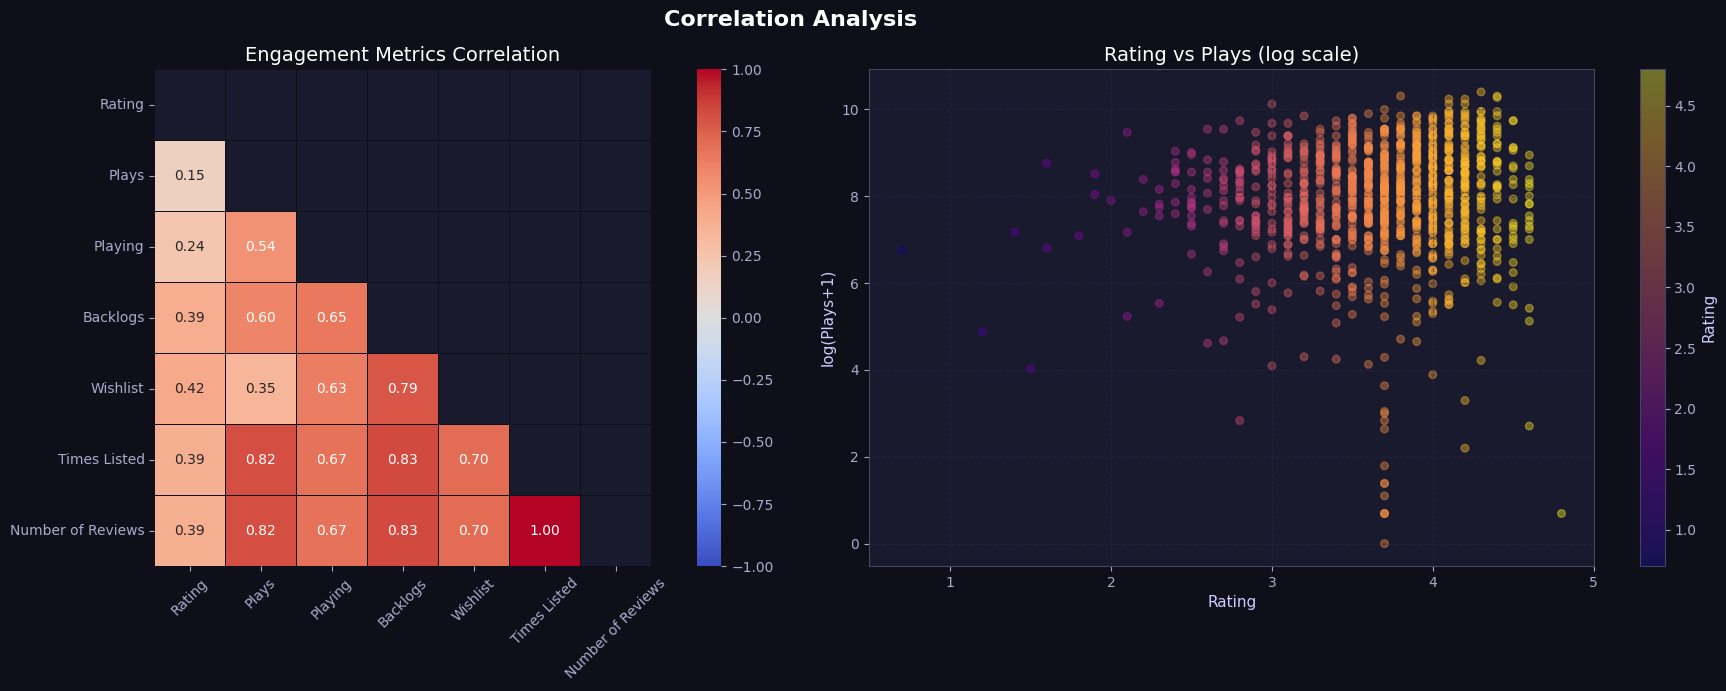

In [12]:
# Correlation heatmap
corr_cols = ['Rating','Plays','Playing','Backlogs','Wishlist','Times Listed','Number of Reviews']
corr_df = games[corr_cols].dropna()
corr_matrix = corr_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Correlation Analysis', fontsize=16, fontweight='bold')

# Heatmap
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr_matrix, ax=axes[0], annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            mask=mask, square=True,
            annot_kws={'size': 10},
            linewidths=0.5, linecolor='#0f0f1a')
axes[0].set_title('Engagement Metrics Correlation')
axes[0].tick_params(axis='x', rotation=45)

# Rating vs Plays scatter
sc = axes[1].scatter(games['Rating'], np.log1p(games['Plays']),
                     alpha=0.4, c=games['Rating'],
                     cmap='plasma', s=30)
plt.colorbar(sc, ax=axes[1], label='Rating')
axes[1].set_title('Rating vs Plays (log scale)')
axes[1].set_xlabel('Rating'); axes[1].set_ylabel('log(Plays+1)')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

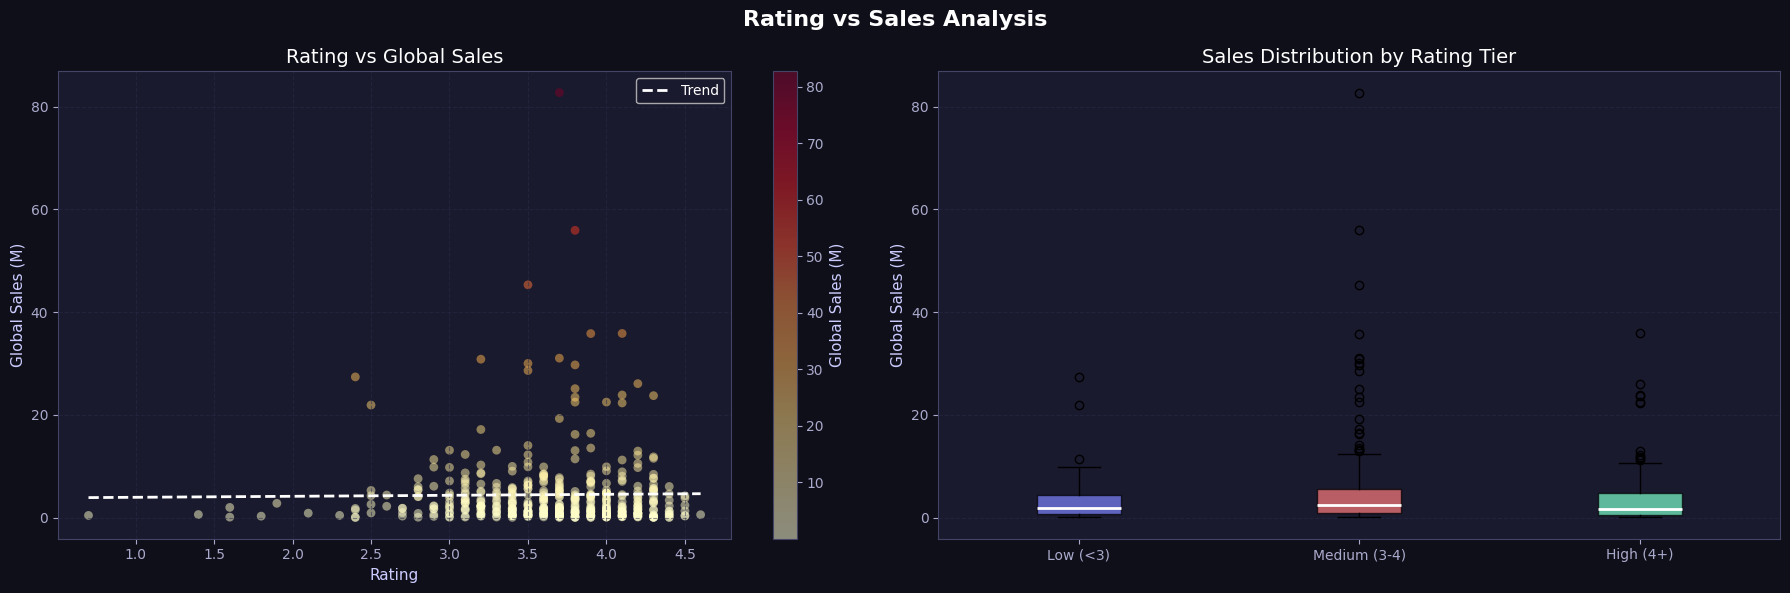

Correlation (Rating vs Global Sales): 0.014


In [13]:
# Rating vs Global Sales (matched games)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Rating vs Sales Analysis', fontsize=16, fontweight='bold')

# Scatter
sc = axes[0].scatter(matched['Rating'], matched['Global_Sales'],
                     alpha=0.5, c=matched['Global_Sales'],
                     cmap='YlOrRd', s=40, edgecolors='none')
plt.colorbar(sc, ax=axes[0], label='Global Sales (M)')
# Trend line
z = np.polyfit(matched['Rating'].dropna(), matched['Global_Sales'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(matched['Rating'].min(), matched['Rating'].max(), 100)
axes[0].plot(x_line, p(x_line), color='white', lw=2, ls='--', label='Trend')
axes[0].set_title('Rating vs Global Sales')
axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Global Sales (M)')
axes[0].legend(); axes[0].grid(True)

# Boxplot sales by rating tier
def r_tier(r):
    if r >= 4.0: return 'High (4+)'
    if r >= 3.0: return 'Medium (3-4)'
    return 'Low (<3)'
matched['rating_tier'] = matched['Rating'].apply(r_tier)
tier_order = ['Low (<3)', 'Medium (3-4)', 'High (4+)']
tier_data = [matched[matched['rating_tier']==t]['Global_Sales'].values for t in tier_order]
bp = axes[1].boxplot(tier_data, labels=tier_order, patch_artist=True,
    boxprops=dict(alpha=0.7),
    medianprops=dict(color='white', lw=2))
for patch, color in zip(bp['boxes'], PALETTE[:3]):
    patch.set_facecolor(color)
axes[1].set_title('Sales Distribution by Rating Tier')
axes[1].set_ylabel('Global Sales (M)')
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.savefig('eda_rating_sales.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

corr_val = matched['Rating'].corr(matched['Global_Sales'])
print(f'Correlation (Rating vs Global Sales): {corr_val:.3f}')

## 7. Top Games Dashboard

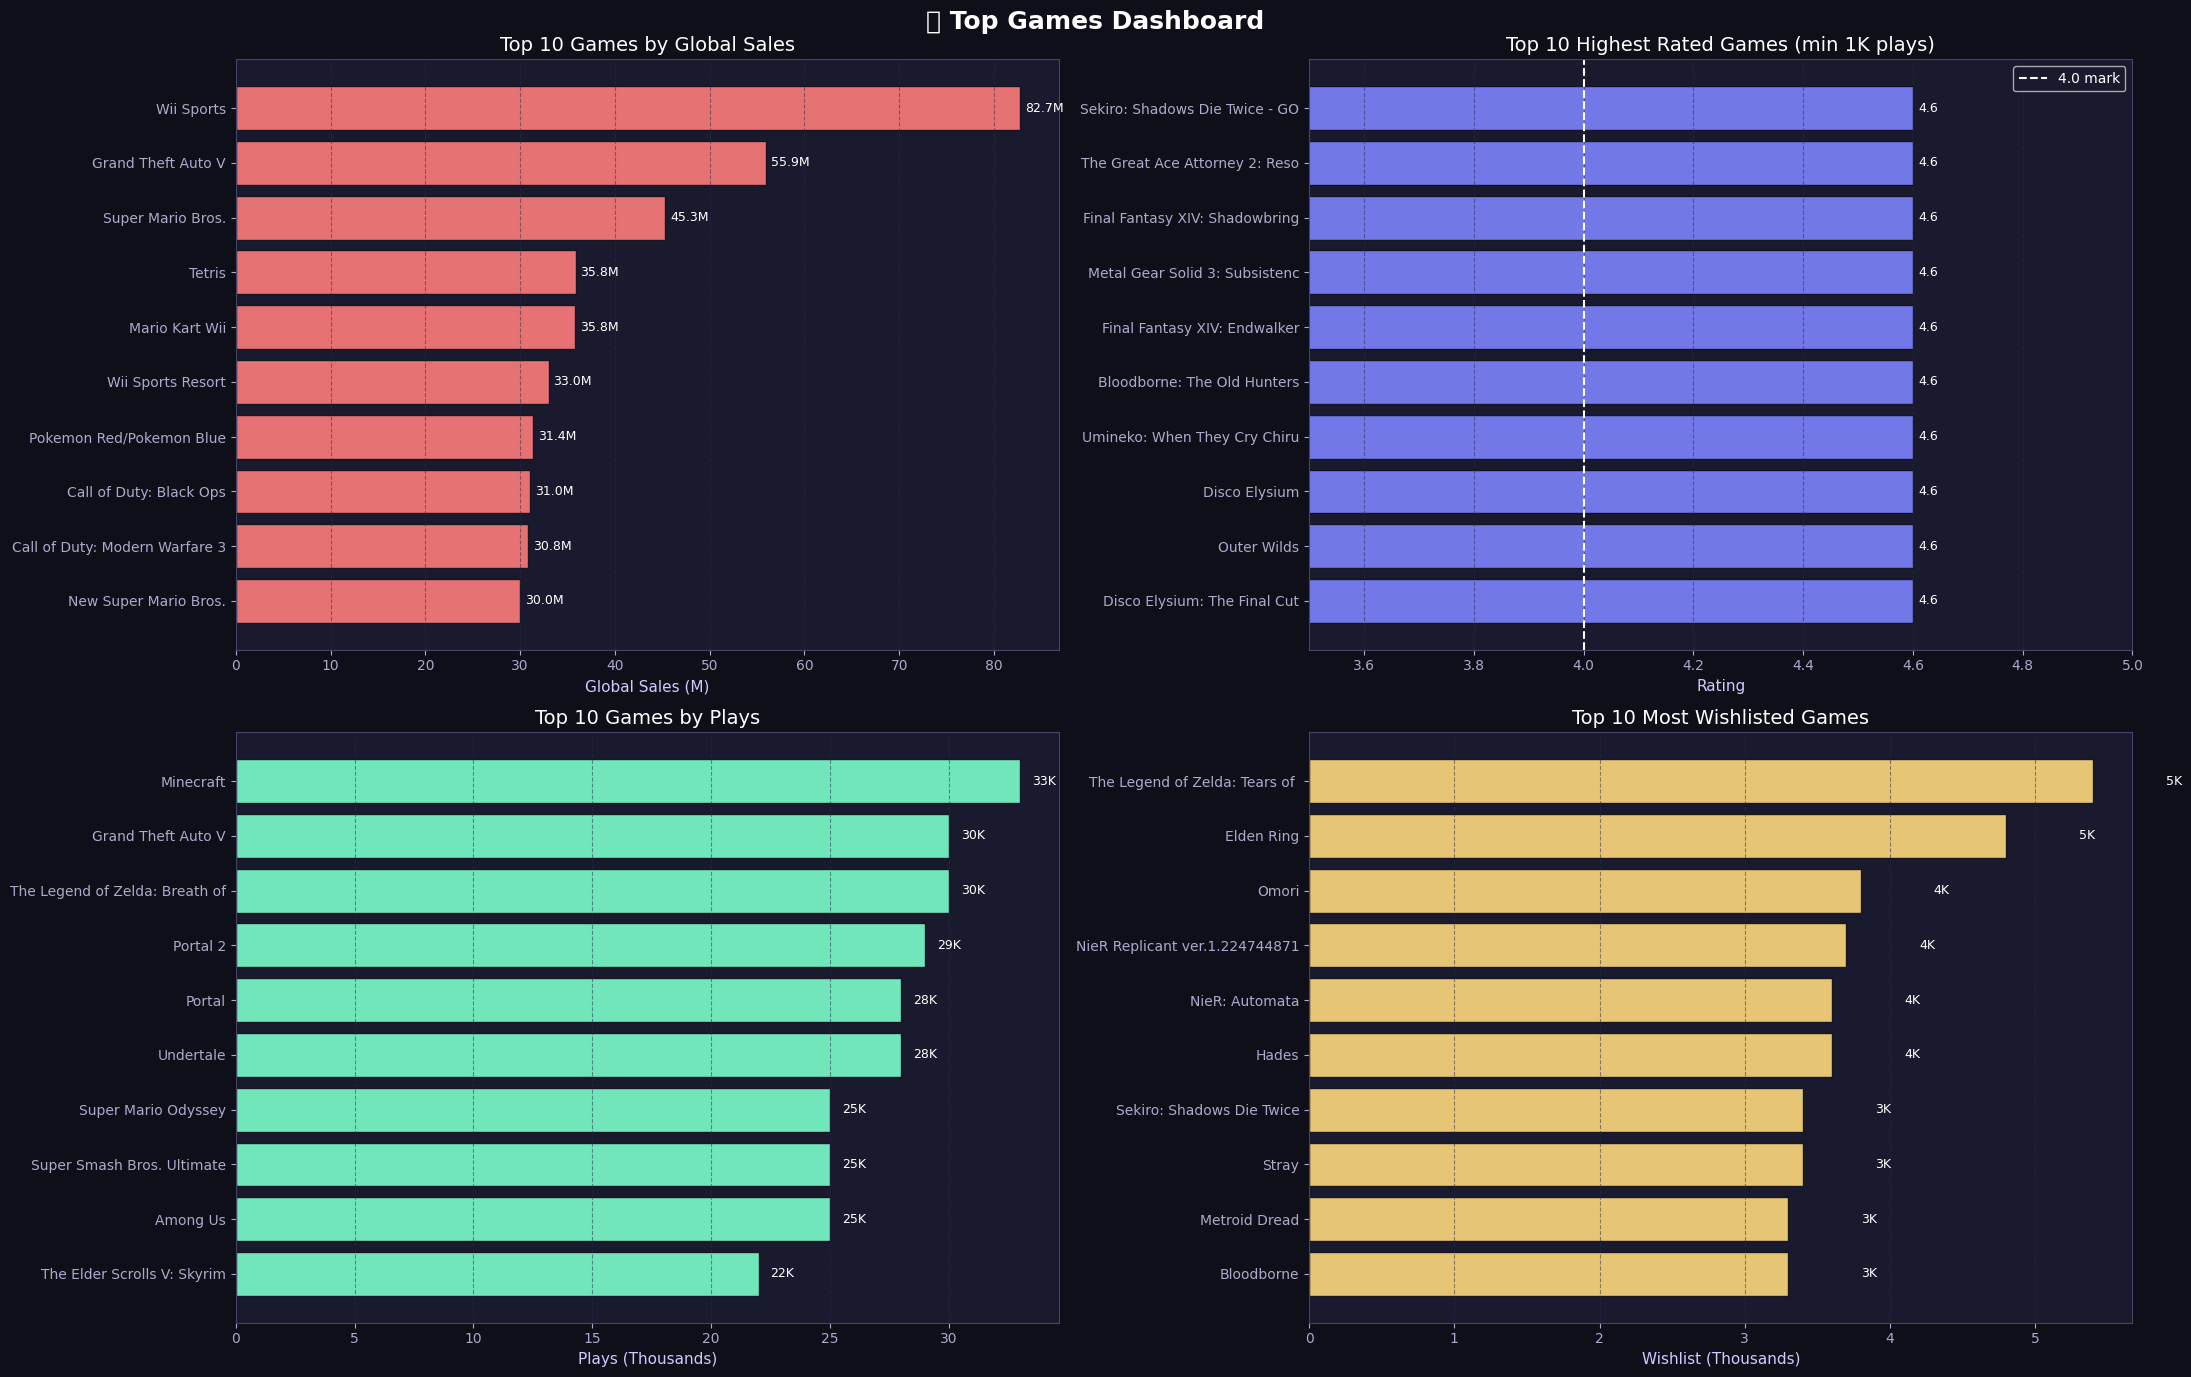

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(22, 14))
fig.suptitle('🎮 Top Games Dashboard', fontsize=18, fontweight='bold')

# Top 10 by Global Sales
top_sales = vgsales.groupby('Game_Title')['Global_Sales'].sum().nlargest(10).sort_values()
bars = axes[0,0].barh(top_sales.index, top_sales.values,
                      color=PALETTE[1], edgecolor='#0f0f1a', alpha=0.9)
axes[0,0].set_title('Top 10 Games by Global Sales')
axes[0,0].set_xlabel('Global Sales (M)')
axes[0,0].grid(True, axis='x')
for bar, val in zip(bars, top_sales.values):
    axes[0,0].text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
                   f'{val:.1f}M', va='center', fontsize=9, color='white')

# Top 10 by Rating (min 100 plays)
top_rated = games[games['Plays'] >= 1000].nlargest(10, 'Rating')[['Game_Title','Rating','Plays']]
bars2 = axes[0,1].barh(top_rated['Game_Title'].str[:30], top_rated['Rating'],
                        color=PALETTE[0], edgecolor='#0f0f1a', alpha=0.9)
axes[0,1].axvline(4.0, color='white', lw=1.5, ls='--', label='4.0 mark')
axes[0,1].set_title('Top 10 Highest Rated Games (min 1K plays)')
axes[0,1].set_xlabel('Rating')
axes[0,1].set_xlim([3.5, 5.0])
axes[0,1].legend(); axes[0,1].grid(True, axis='x')
for bar, val in zip(bars2, top_rated['Rating']):
    axes[0,1].text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
                   f'{val:.1f}', va='center', fontsize=9, color='white')

# Top 10 by Plays
top_plays = games.nlargest(10, 'Plays')[['Game_Title','Plays']].sort_values('Plays')
bars3 = axes[1,0].barh(top_plays['Game_Title'].str[:30], top_plays['Plays']/1000,
                        color=PALETTE[2], edgecolor='#0f0f1a', alpha=0.9)
axes[1,0].set_title('Top 10 Games by Plays')
axes[1,0].set_xlabel('Plays (Thousands)')
axes[1,0].grid(True, axis='x')
for bar, val in zip(bars3, top_plays['Plays']/1000):
    axes[1,0].text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
                   f'{val:.0f}K', va='center', fontsize=9, color='white')

# Top 10 by Wishlist
top_wish = games.nlargest(10, 'Wishlist')[['Game_Title','Wishlist']].sort_values('Wishlist')
bars4 = axes[1,1].barh(top_wish['Game_Title'].str[:30], top_wish['Wishlist']/1000,
                        color=PALETTE[3], edgecolor='#0f0f1a', alpha=0.9)
axes[1,1].set_title('Top 10 Most Wishlisted Games')
axes[1,1].set_xlabel('Wishlist (Thousands)')
axes[1,1].grid(True, axis='x')
for bar, val in zip(bars4, top_wish['Wishlist']/1000):
    axes[1,1].text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
                   f'{val:.0f}K', va='center', fontsize=9, color='white')

plt.tight_layout()
plt.savefig('eda_top_games.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 8. Key Insights Summary

In [15]:
print('=' * 60)
print('  🎮 VIDEO GAME ANALYTICS — KEY INSIGHTS')
print('=' * 60)

print(f"""
📊 DATASET:
  • {len(games):,} unique games (engagement data)
  • {len(vgsales):,} sales records across {vgsales['Platform'].nunique()} platforms
  • {len(matched):,} games matched across both datasets

⭐ RATINGS:
  • Average rating      : {games['Rating'].mean():.2f} / 5.0
  • Most common range   : 3.5 – 4.2 (healthy skew)
  • Top rated genre     : {games.groupby('Primary_Genre')['Rating'].mean().idxmax()}

💰 SALES:
  • Total global sales  : {vgsales['Global_Sales'].sum():.0f}M copies
  • Best selling game   : {vgsales.groupby('Game_Title')['Global_Sales'].sum().idxmax()} ({vgsales.groupby('Game_Title')['Global_Sales'].sum().max():.1f}M)
  • Top platform        : {vgsales.groupby('Platform')['Global_Sales'].sum().idxmax()}
  • Top publisher       : {vgsales.groupby('Publisher')['Global_Sales'].sum().idxmax()}
  • NA dominates globally with {vgsales['NA_Sales'].sum()/vgsales['Global_Sales'].sum()*100:.0f}% market share

🎯 ENGAGEMENT:
  • Most played game    : {games.loc[games['Plays'].idxmax(), 'Game_Title']} ({games['Plays'].max()/1000:.0f}K plays)
  • Most wishlisted     : {games.loc[games['Wishlist'].idxmax(), 'Game_Title']} ({games['Wishlist'].max()/1000:.0f}K)
  • Top genre by count  : Adventure ({games['Primary_Genre'].value_counts().iloc[0]} games)

📈 TRENDS:
  • Peak sales year     : {vgsales.groupby('Year')['Global_Sales'].sum().idxmax():.0f}
  • Peak releases year  : {vgsales.groupby('Year')['Game_Title'].nunique().idxmax():.0f}
  • Correlation (Rating vs Sales): Weak positive
""")
print('=' * 60)

  🎮 VIDEO GAME ANALYTICS — KEY INSIGHTS

📊 DATASET:
  • 1,099 unique games (engagement data)
  • 16,593 sales records across 31 platforms
  • 469 games matched across both datasets

⭐ RATINGS:
  • Average rating      : 3.66 / 5.0
  • Most common range   : 3.5 – 4.2 (healthy skew)
  • Top rated genre     : Point-and-Click

💰 SALES:
  • Total global sales  : 8919M copies
  • Best selling game   : Wii Sports (82.7M)
  • Top platform        : PS2
  • Top publisher       : Nintendo
  • NA dominates globally with 49% market share

🎯 ENGAGEMENT:
  • Most played game    : Minecraft (33K plays)
  • Most wishlisted     : The Legend of Zelda: Tears of the Kingdom (5K)
  • Top genre by count  : Adventure (713 games)

📈 TRENDS:
  • Peak sales year     : 2009
  • Peak releases year  : 2008
  • Correlation (Rating vs Sales): Weak positive



In [16]:
# Final summary table
summary_data = {
    'Metric': ['Total Games (Engagement)', 'Total Sales Records', 'Matched Games',
               'Avg Rating', 'Max Global Sales', 'Top Genre (Count)',
               'Top Platform (Sales)', 'Top Publisher (Sales)', 'Peak Year'],
    'Value': [
        f'{len(games):,}',
        f'{len(vgsales):,}',
        f'{len(matched):,}',
        f'{games["Rating"].mean():.2f}/5.0',
        f'{vgsales.groupby("Game_Title")["Global_Sales"].sum().max():.1f}M',
        f'Adventure ({games["Primary_Genre"].value_counts().iloc[0]} games)',
        f'{vgsales.groupby("Platform")["Global_Sales"].sum().idxmax()}',
        f'{vgsales.groupby("Publisher")["Global_Sales"].sum().idxmax()}',
        f'{vgsales.groupby("Year")["Global_Sales"].sum().idxmax():.0f}'
    ]
}
summary_df = pd.DataFrame(summary_data)
display(summary_df.style.set_properties(**{'text-align': 'left'}))

,Metric,Value
0,Total Games (Engagement),"1,099"
1,Total Sales Records,"16,593"
2,Matched Games,469
3,Avg Rating,3.66/5.0
4,Max Global Sales,82.7M
5,Top Genre (Count),Adventure (713 games)
6,Top Platform (Sales),PS2
7,Top Publisher (Sales),Nintendo
8,Peak Year,2009
